## Step 1: Install Dependencies

In [3]:
# Install required packages
!pip install -q roboflow ultralytics sahi pyyaml

import os
import yaml
import random
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- Colab paths (replaces /kaggle/working) ----
WORKING_DIR = '/content'
PROJECT_DIR = '/content/runs'
os.makedirs(PROJECT_DIR, exist_ok=True)

print('✅ All packages installed!')
print(f'Working directory: {WORKING_DIR}')

✅ All packages installed!
Working directory: /content


## Step 2: Download Heridal Dataset via Roboflow

In [4]:
from roboflow import Roboflow

# Load API key from Colab Secrets (recommended)
# To add: click 🔑 icon in left sidebar → Add new secret → ROBOFLOW_API_KEY
try:
    from google.colab import userdata
    ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
    print('✅ API key loaded from Colab Secrets')
except Exception:
    # Fallback: paste key directly (not recommended for shared notebooks)
    ROBOFLOW_API_KEY = "NNm7raTCFUyh6mBoXH75"  # ← Replace this
    print('⚠️  Using hardcoded API key — consider using Colab Secrets')

os.chdir(WORKING_DIR)

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("sar-datasets").project("heridal-dhyqp")
version = project.version(1)
dataset = version.download("yolov8")

print(f'\n✅ Dataset downloaded to: {dataset.location}')

⚠️  Using hardcoded API key — consider using Colab Secrets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to HERIDAL-1 in yolov8:: 100%|██████████| 3160/3160 [00:00<00:00, 4792.79it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

✅ Dataset downloaded to: /content/HERIDAL-1


## Step 3: Explore Dataset Structure

In [5]:
dataset_path = dataset.location

print('📁 Dataset Structure:')
print('=' * 40)
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}📁 {os.path.basename(root)}/')
    if level < 2:
        subindent = '  ' * (level + 1)
        print(f'{subindent}({len(files)} files)')

print('\n📄 data.yaml contents:')
print('=' * 40)
with open(f"{dataset_path}/data.yaml", "r") as f:
    data_cfg = yaml.safe_load(f)
print(yaml.dump(data_cfg, default_flow_style=False))

📁 Dataset Structure:
📁 HERIDAL-1/
  (3 files)
  📁 train/
    (0 files)
    📁 images/
    📁 labels/

📄 data.yaml contents:
names:
- person
nc: 1
roboflow:
  license: CC BY 4.0
  project: heridal-dhyqp
  url: https://universe.roboflow.com/sar-datasets/heridal-dhyqp/dataset/1
  version: 1
  workspace: sar-datasets
test: ../test/images
train: ../train/images
val: ../valid/images



## Step 4: Train / Val / Test Split

In [6]:
# ---- Detect available source splits ----
src_images = None
src_labels = None

for candidate in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_path, candidate, 'images')
    lbl_dir = os.path.join(dataset_path, candidate, 'labels')
    if os.path.isdir(img_dir) and len(os.listdir(img_dir)) > 0:
        src_images = img_dir
        src_labels = lbl_dir
        print(f'✅ Source split found: {candidate}/ ({len(os.listdir(img_dir))} images)')
        break

if src_images is None:
    raise FileNotFoundError('No images found in dataset. Check download.')

# ---- Create clean split directory ----
split_path = "/content/split_dataset"

if os.path.exists(split_path):
    shutil.rmtree(split_path)

for split in ['train', 'valid', 'test']:
    os.makedirs(f"{split_path}/{split}/images", exist_ok=True)
    os.makedirs(f"{split_path}/{split}/labels", exist_ok=True)

# ---- Shuffle and split ----
all_images = [f for f in os.listdir(src_images) if f.endswith(('.jpg', '.jpeg', '.png'))]
random.seed(42)
random.shuffle(all_images)

train_ratio, val_ratio = 0.70, 0.20
train_end = int(len(all_images) * train_ratio)
val_end   = int(len(all_images) * (train_ratio + val_ratio))

splits = {
    'train': all_images[:train_end],
    'valid': all_images[train_end:val_end],
    'test' : all_images[val_end:]
}

# ---- Copy files ----
copied = {'train': 0, 'valid': 0, 'test': 0}
for split, files in splits.items():
    for img_file in files:
        shutil.copy(os.path.join(src_images, img_file),
                    os.path.join(split_path, split, 'images', img_file))
        stem = os.path.splitext(img_file)[0]
        lbl_file = stem + '.txt'
        lbl_src  = os.path.join(src_labels, lbl_file)
        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, os.path.join(split_path, split, 'labels', lbl_file))
        copied[split] += 1

print('\n📊 Split Summary:')
print('=' * 30)
for split, count in copied.items():
    print(f'  {split:<8}: {count:>5} images')
print(f'\n✅ Dataset split completed!')

✅ Source split found: train/ (1577 images)

📊 Split Summary:
  train   :  1103 images
  valid   :   316 images
  test    :   158 images

✅ Dataset split completed!


## Step 5: Create data.yaml for Training

In [7]:
data_yaml_content = {
    'path' : split_path,
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : 1,
    'names': ['person']
}

yaml_path = os.path.join(split_path, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print('✅ data.yaml written:')
print('=' * 40)
with open(yaml_path) as f:
    print(f.read())

✅ data.yaml written:
names:
- person
nc: 1
path: /content/split_dataset
test: test/images
train: train/images
val: valid/images



## Step 6: Dataset Analysis

In [8]:
def analyze_split(img_dir, lbl_dir, name):
    images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    total_objects = 0
    empty_images  = 0

    for img_file in images:
        stem     = os.path.splitext(img_file)[0]
        lbl_file = os.path.join(lbl_dir, stem + '.txt')
        if os.path.exists(lbl_file):
            with open(lbl_file) as f:
                lines = f.readlines()
            total_objects += len(lines)
            if len(lines) == 0:
                empty_images += 1
        else:
            empty_images += 1

    avg = total_objects / len(images) if images else 0
    print(f'\n{name} SET')
    print('-' * 30)
    print(f'  Images            : {len(images)}')
    print(f'  Total objects     : {total_objects}')
    print(f'  Avg objects/image : {avg:.2f}')
    print(f'  Empty images      : {empty_images}')

analyze_split(f'{split_path}/train/images', f'{split_path}/train/labels', 'TRAIN')
analyze_split(f'{split_path}/valid/images', f'{split_path}/valid/labels', 'VALIDATION')
analyze_split(f'{split_path}/test/images',  f'{split_path}/test/labels',  'TEST')


TRAIN SET
------------------------------
  Images            : 1103
  Total objects     : 2229
  Avg objects/image : 2.02
  Empty images      : 381

VALIDATION SET
------------------------------
  Images            : 316
  Total objects     : 604
  Avg objects/image : 1.91
  Empty images      : 109

TEST SET
------------------------------
  Images            : 158
  Total objects     : 244
  Avg objects/image : 1.54
  Empty images      : 69


📏 BOUNDING BOX SIZE ANALYSIS (Tiny Objects Check)
  Total annotations : 2229
  Min area          : 0.000055
  Max area          : 0.001604
  Mean area         : 0.000353
  Avg width         : 0.016012
  Avg height        : 0.021258


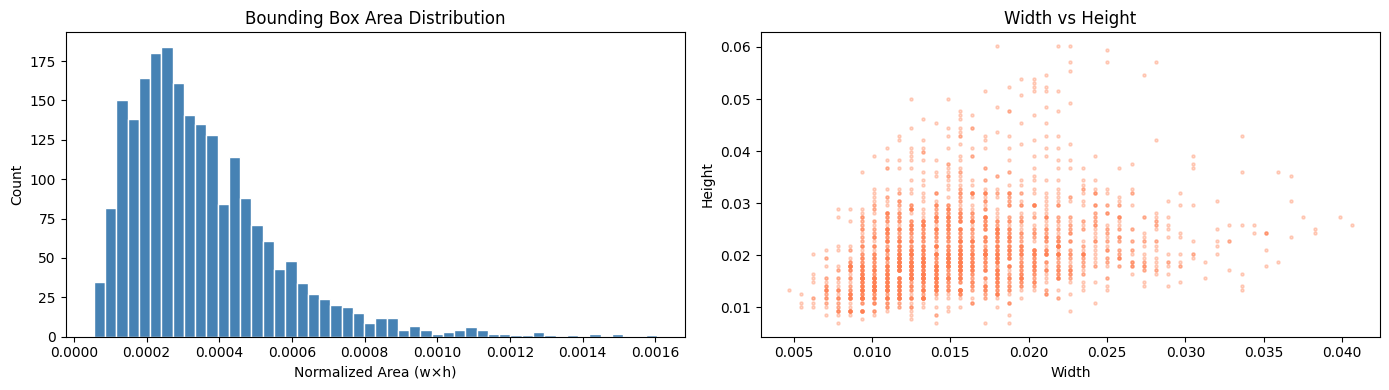

In [9]:
# Bounding box size analysis
areas, widths, heights = [], [], []
label_dir = f'{split_path}/train/labels'

for lbl_file in os.listdir(label_dir):
    with open(os.path.join(label_dir, lbl_file)) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, x, y, w, h = map(float, parts)
                areas.append(w * h)
                widths.append(w)
                heights.append(h)

areas = np.array(areas)
print('📏 BOUNDING BOX SIZE ANALYSIS (Tiny Objects Check)')
print('=' * 45)
print(f'  Total annotations : {len(areas)}')
print(f'  Min area          : {areas.min():.6f}')
print(f'  Max area          : {areas.max():.6f}')
print(f'  Mean area         : {areas.mean():.6f}')
print(f'  Avg width         : {np.mean(widths):.6f}')
print(f'  Avg height        : {np.mean(heights):.6f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(areas, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Bounding Box Area Distribution')
axes[0].set_xlabel('Normalized Area (w×h)')
axes[0].set_ylabel('Count')

axes[1].scatter(widths, heights, alpha=0.3, s=5, color='coral')
axes[1].set_title('Width vs Height')
axes[1].set_xlabel('Width')
axes[1].set_ylabel('Height')

plt.tight_layout()
plt.show()

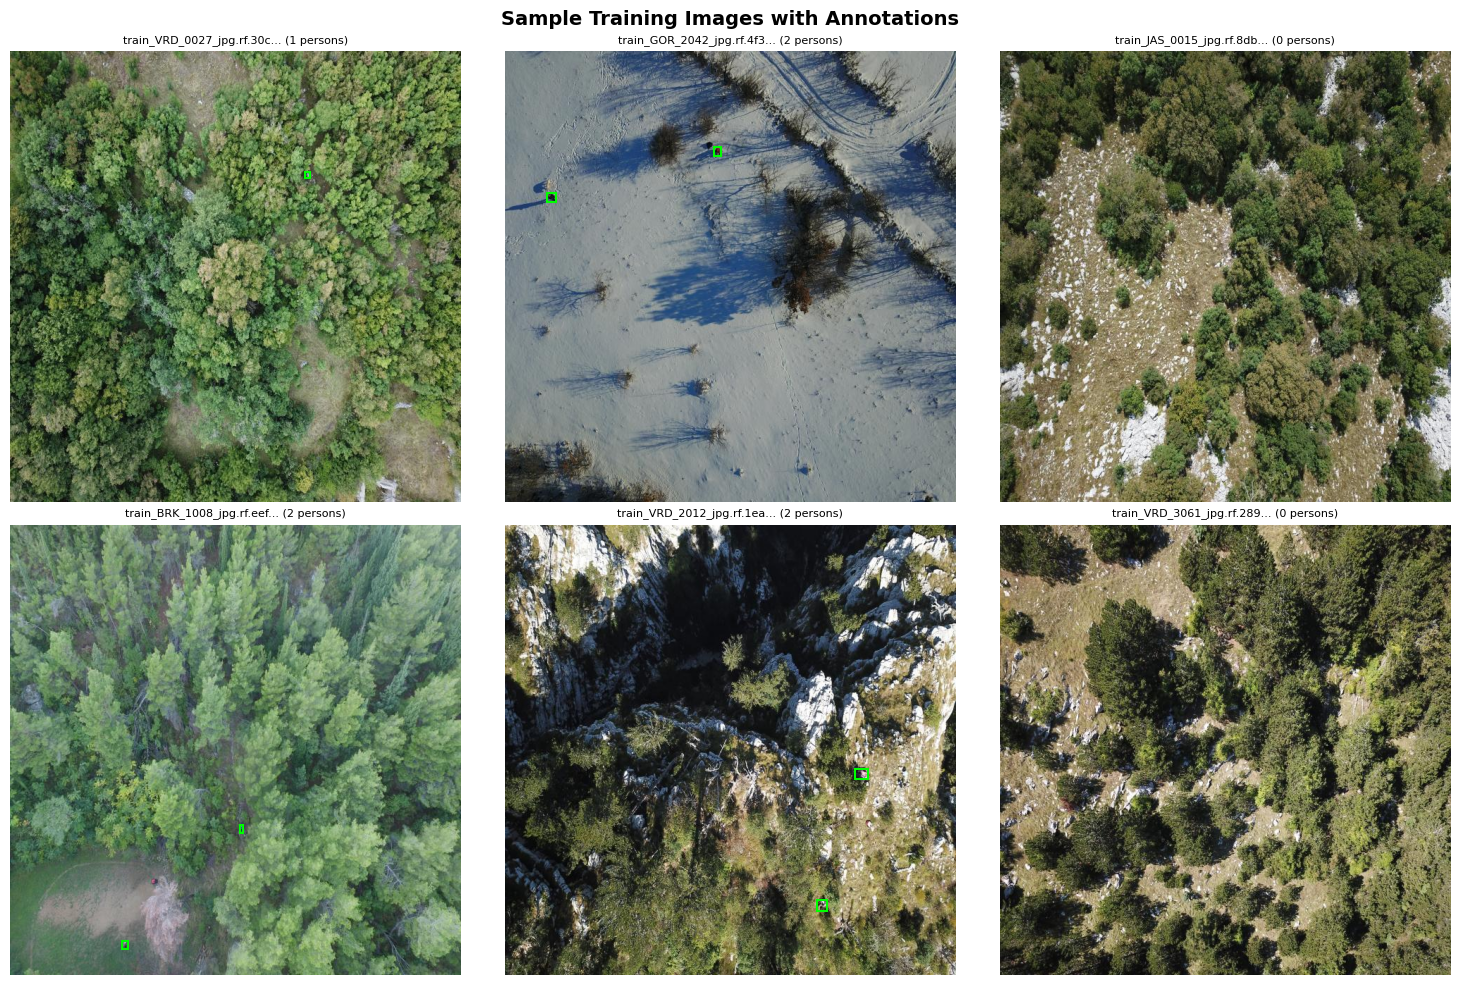

In [10]:
# Visualize sample images with bounding boxes
img_dir = f'{split_path}/train/images'
lbl_dir = f'{split_path}/train/labels'
sample_files = random.sample(os.listdir(img_dir), min(6, len(os.listdir(img_dir))))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_file in enumerate(sample_files):
    img = cv2.imread(os.path.join(img_dir, img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax = axes[i]
    ax.imshow(img)

    stem     = os.path.splitext(img_file)[0]
    lbl_file = os.path.join(lbl_dir, stem + '.txt')
    n_boxes  = 0

    if os.path.exists(lbl_file):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, cx, cy, bw, bh = map(float, parts)
                    x1 = max(0, (cx - bw/2) * w)
                    y1 = max(0, (cy - bh/2) * h)
                    bw_px = bw * w
                    bh_px = bh * h
                    rect = patches.Rectangle((x1, y1), bw_px, bh_px,
                                             linewidth=1.5, edgecolor='lime', facecolor='none')
                    ax.add_patch(rect)
                    n_boxes += 1

    ax.set_title(f'{img_file[:25]}... ({n_boxes} persons)', fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Training Images with Annotations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7: YOLOv8 Baseline (Comparison)

> We train **YOLOv8-L** for a reduced number of epochs as a **baseline** to compare against RT-DETR.
> YOLOv8 is the state-of-the-art anchor-free CNN detector; RT-DETR is transformer-based.
> This lets us directly measure the improvement from switching architectures.

In [11]:
import torch
print(f'CUDA available : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU            : {torch.cuda.get_device_name(0)}')
    print(f'VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU detected! Training will be very slow on CPU.')

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
IMGSZ  = 800

CUDA available : True
GPU            : Tesla T4
VRAM           : 15.6 GB


In [12]:
from ultralytics import YOLO

# ---- YOLOv8 Baseline Config ----
YOLOv8_EPOCHS  = 30          # Fewer epochs — baseline, not full training
YOLOv8_BATCH   = 8
YOLOv8_PROJECT = PROJECT_DIR
YOLOv8_NAME    = 'yolov8_heridal_baseline'

yolo_model = YOLO('yolov8l.pt')   # Large variant for fair comparison with rtdetr-l

print('🚀 Starting YOLOv8-L Baseline Training...')
print(f'   Epochs : {YOLOv8_EPOCHS}  |  Batch: {YOLOv8_BATCH}  |  ImgSz: {IMGSZ}')

yolo_results = yolo_model.train(
    data     = yaml_path,
    epochs   = YOLOv8_EPOCHS,
    imgsz    = IMGSZ,
    batch    = YOLOv8_BATCH,
    device   = DEVICE,

    # Same augmentation as RT-DETR for fair comparison
    lr0          = 1e-3,
    lrf          = 0.01,
    warmup_epochs= 3,
    weight_decay = 5e-4,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    degrees      = 10,
    translate    = 0.1,
    scale        = 0.5,
    flipud       = 0.5,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
    copy_paste   = 0.1,

    patience  = 15,
    project   = YOLOv8_PROJECT,
    name      = YOLOv8_NAME,
    exist_ok  = True
)

print('\n✅ YOLOv8 baseline training completed!')
yolo_best_weights = f'{YOLOv8_PROJECT}/{YOLOv8_NAME}/weights/best.pt'
print(f'Best weights saved at: {yolo_best_weights}')

🚀 Starting YOLOv8-L Baseline Training...
   Epochs : 30  |  Batch: 8  |  ImgSz: 800
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/split_dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_heridal_basel

In [13]:
# ---- Evaluate YOLOv8 Baseline ----
yolo_eval_model = YOLO(yolo_best_weights)

yolo_metrics = yolo_eval_model.val(
    data   = yaml_path,
    imgsz  = IMGSZ,
    device = DEVICE
)

# Store results for comparison
yolo_map50    = yolo_metrics.box.map50
yolo_map5095  = yolo_metrics.box.map
yolo_precision = yolo_metrics.box.mp
yolo_recall   = yolo_metrics.box.mr

print('\n📊 YOLOv8-L BASELINE RESULTS')
print('=' * 35)
print(f'  mAP@50      : {yolo_map50:.4f}')
print(f'  mAP@50-95   : {yolo_map5095:.4f}')
print(f'  Precision   : {yolo_precision:.4f}')
print(f'  Recall      : {yolo_recall:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2811.8±821.8 MB/s, size: 100.2 KB)
val: Scanning /content/split_dataset/valid/labels.cache... 316 images, 109 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 316/316 120.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.1s/it 21.6s
                   all        316        604      0.635      0.518      0.535      0.211
Speed: 2.9ms preprocess, 61.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val

📊 YOLOv8-L BASELINE RESULTS
  mAP@50      : 0.5350
  mAP@50-95   : 0.2107
  Precision   : 0.6348
  Recall      : 0.5182


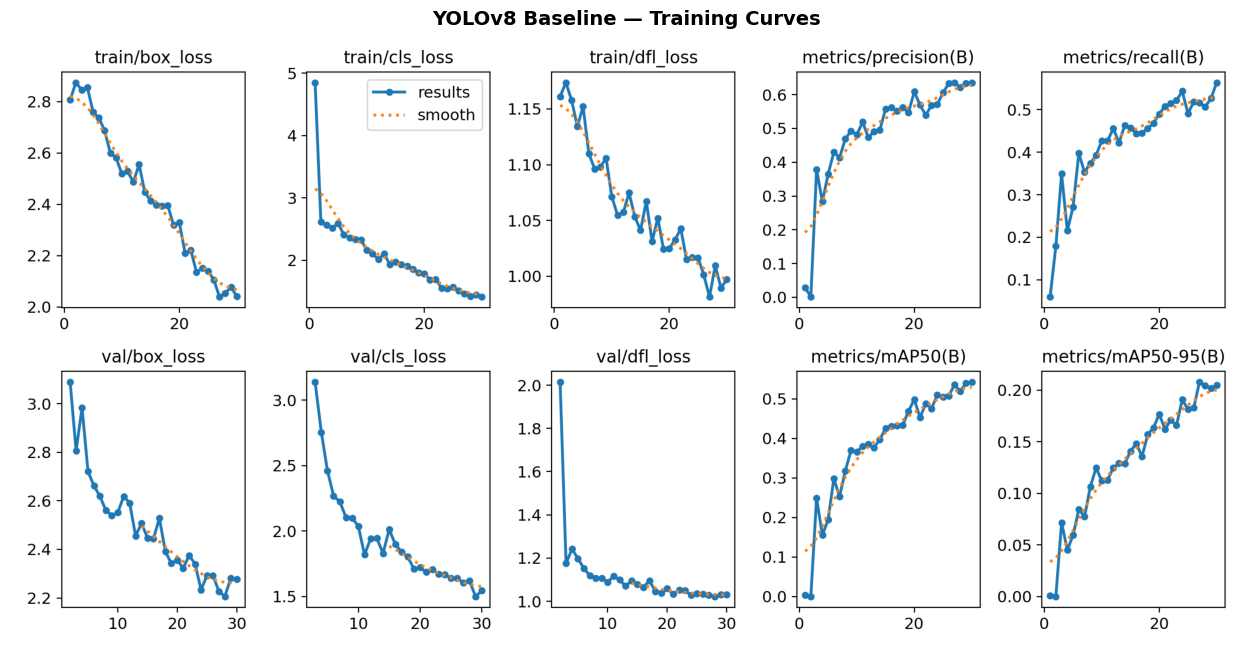

In [14]:
# Show YOLOv8 training curves
yolo_results_png = f'{YOLOv8_PROJECT}/{YOLOv8_NAME}/results.png'
if os.path.exists(yolo_results_png):
    img = plt.imread(yolo_results_png)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('YOLOv8 Baseline — Training Curves', fontsize=14, fontweight='bold')
    plt.show()

---
## Step 8: Train RT-DETR Model (Main)

> ⚠️ **GPU Required** — Ensure runtime type is set to GPU.

In [15]:
from ultralytics import RTDETR

BATCH   = 8
EPOCHS  = 70
NAME    = 'rtdetr_heridal'

model = RTDETR('rtdetr-l.pt')  # Downloads pretrained weights automatically

print('🚀 Starting RT-DETR Training...')
print(f'   Epochs : {EPOCHS}  |  Batch: {BATCH}  |  ImgSz: {IMGSZ}')

results = model.train(
    data     = yaml_path,
    epochs   = EPOCHS,
    imgsz    = IMGSZ,
    batch    = BATCH,
    device   = DEVICE,

    # Optimizer
    lr0          = 1e-4,
    lrf          = 0.01,
    warmup_epochs= 5,
    weight_decay = 5e-4,

    # Augmentation (important for tiny objects)
    hsv_h    = 0.015,
    hsv_s    = 0.7,
    hsv_v    = 0.4,
    degrees  = 10,
    translate= 0.1,
    scale    = 0.5,
    flipud   = 0.5,
    fliplr   = 0.5,
    mosaic   = 1.0,
    mixup    = 0.1,
    copy_paste = 0.1,

    patience = 20,

    project  = PROJECT_DIR,
    name     = NAME,
    exist_ok = True
)

print('\n✅ RT-DETR Training completed!')
best_weights = f'{PROJECT_DIR}/{NAME}/weights/best.pt'
print(f'Best weights saved at: {best_weights}')

🚀 Starting RT-DETR Training...
   Epochs : 70  |  Batch: 8  |  ImgSz: 800
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/split_dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_heridal, nbs=64, nms=

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       1/70      9.57G      1.462       1.44     0.3167         25        800: 100% ━━━━━━━━━━━━ 138/138 1.0it/s 2:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.5it/s 13.0s
                   all        316        604      0.485      0.483      0.414       0.15

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       2/70      9.93G      1.027     0.5466     0.1059         14        800: 100% ━━━━━━━━━━━━ 138/138 1.1it/s 2:05
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.2it/s 9.1s
                   all        316        604       0.54       0.46      0.446      0.157

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/70      9.85G     0.9442     0.5264     0.0593         22        800: 0% ──────────── 0/138  0.9s

...

      68/70      9.87G     0.6059     0.4798    0.04055          8        800: 100% ━━━━━━━━━━━━ 138/138 1.2it/s 1:59
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.2it/s 9.0s
                   all        316        604      0.803      0.677      0.725      0.322

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      69/70       9.9G     0.6292     0.7246    0.04959         25        800: 0% ──────────── 0/138  0.9s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      69/70       9.9G     0.5894     0.4859    0.03913         34        800: 100% ━━━━━━━━━━━━ 138/138 1.2it/s 1:60
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.2it/s 8.9s
                   all        316        604      0.779      0.684      0.715      0.313

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      70/70      9.86G     0.6732     0.4714    0.04327         13        800: 0% ──────────── 0/138  0.9s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      70/70      9.86G     0.5984     0.4793    0.03658         11        800: 100% ━━━━━━━━━━━━ 138/138 1.2it/s 1:59
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.2it/s 9.1s
                   all        316        604      0.804      0.695       0.72      0.314

70 epochs completed in 3.107 hours.
Optimizer stripped from /content/runs/rtdetr_heridal/weights/last.pt, 66.3MB
Optimizer stripped from /content/runs/rtdetr_heridal/weights/best.pt, 66.3MB

Validating /content/runs/rtdetr_heridal/weights/best.pt...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 2.0it/s 10.1s
                   all        316        604        0.8      0.674      0.725      0.322
Speed: 0.3ms preprocess, 26.4ms inf

##  Step 9: Evaluate RT-DETR

In [16]:
rtdetr_eval = RTDETR(best_weights)

metrics = rtdetr_eval.val(
    data   = yaml_path,
    imgsz  = IMGSZ,
    device = DEVICE
)

# Store results for comparison
rtdetr_map50    = metrics.box.map50
rtdetr_map5095  = metrics.box.map
rtdetr_precision = metrics.box.mp
rtdetr_recall   = metrics.box.mr

print('\n📊 RT-DETR EVALUATION METRICS')
print('=' * 35)
print(f'  mAP@50      : {rtdetr_map50:.4f}')
print(f'  mAP@50-95   : {rtdetr_map5095:.4f}')
print(f'  Precision   : {rtdetr_precision:.4f}')
print(f'  Recall      : {rtdetr_recall:.4f}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2469.1±787.6 MB/s, size: 111.4 KB)
val: Scanning /content/split_dataset/valid/labels.cache... 316 images, 109 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 316/316 147.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 1.0s/it 20.7s
                   all        316        604      0.806      0.685      0.731      0.325
Speed: 4.9ms preprocess, 56.5ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val-2

📊 RT-DETR EVALUATION METRICS
  mAP@50      : 0.7306
  mAP@50-95   : 0.3251
  Precision   : 0.8065
  Recall      : 0.6854


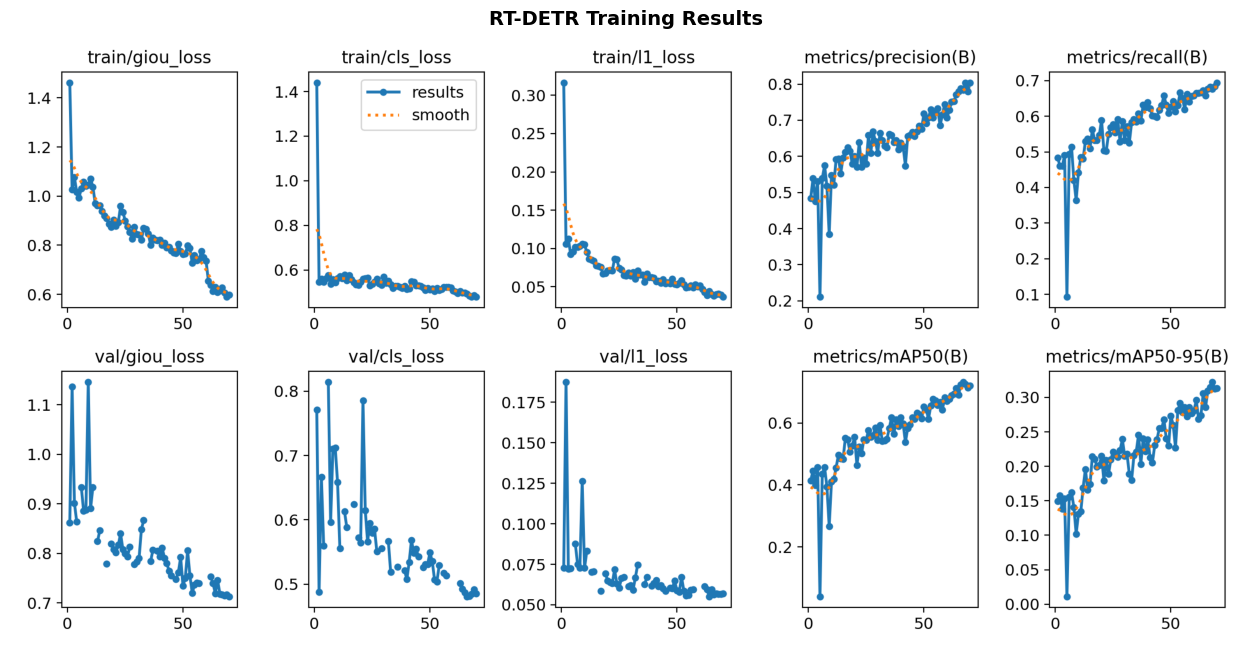

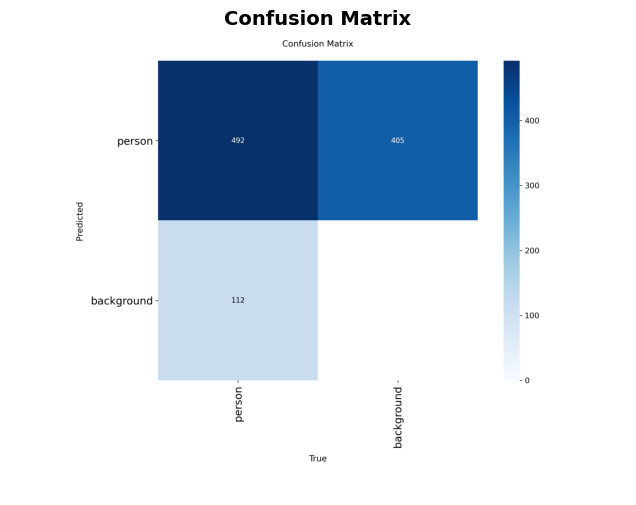

In [17]:
# Display RT-DETR training curves
results_png = f'{PROJECT_DIR}/{NAME}/results.png'
if os.path.exists(results_png):
    img = plt.imread(results_png)
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('RT-DETR Training Results', fontsize=14, fontweight='bold')
    plt.show()

conf_matrix = f'{PROJECT_DIR}/{NAME}/confusion_matrix.png'
if os.path.exists(conf_matrix):
    img = plt.imread(conf_matrix)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
    plt.show()

## Step 10: Model Comparison — YOLOv8 vs RT-DETR


Metric             YOLOv8-L (30ep)   RT-DETR-L (70ep)    Delta
mAP@50                      0.5350             0.7306 ▲0.1956
mAP@50-95                   0.2107             0.3251 ▲0.1144
Precision                   0.6348             0.8065 ▲0.1717
Recall                      0.5182             0.6854 ▲0.1672


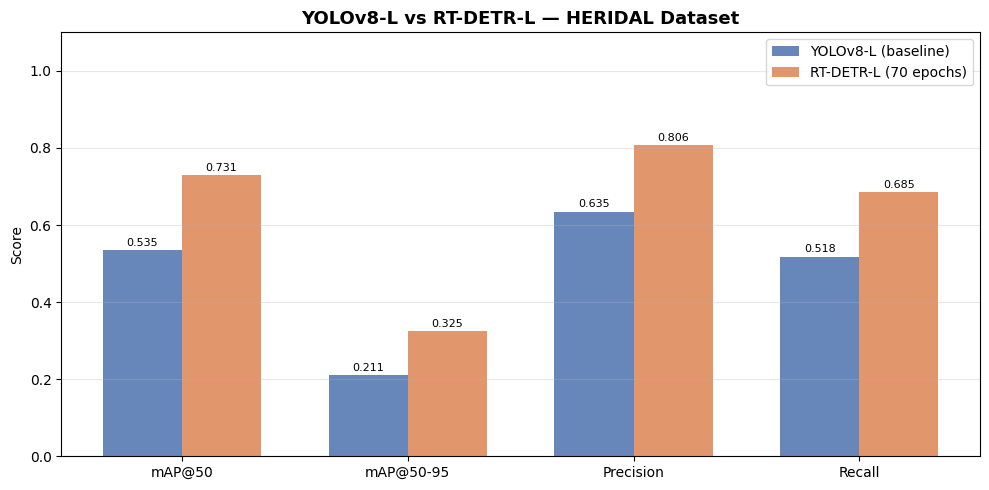


✅ Comparison chart saved to /content/model_comparison.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Comparison Table ----
metrics_names = ['mAP@50', 'mAP@50-95', 'Precision', 'Recall']
yolo_scores   = [yolo_map50, yolo_map5095, yolo_precision, yolo_recall]
rtdetr_scores = [rtdetr_map50, rtdetr_map5095, rtdetr_precision, rtdetr_recall]

print('\n' + '='*55)
print(f"{'Metric':<15} {'YOLOv8-L (30ep)':>18} {'RT-DETR-L (70ep)':>18} {'Delta':>8}")
print('='*55)
for name, y, r in zip(metrics_names, yolo_scores, rtdetr_scores):
    delta = r - y
    arrow = '▲' if delta > 0 else '▼'
    print(f"{name:<15} {y:>18.4f} {r:>18.4f} {arrow}{abs(delta):>6.4f}")
print('='*55)

# ---- Bar chart comparison ----
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, yolo_scores,   width, label='YOLOv8-L (baseline)',  color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, rtdetr_scores, width, label='RT-DETR-L (70 epochs)', color='#DD8452', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('YOLOv8-L vs RT-DETR-L — HERIDAL Dataset', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate bars
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Comparison chart saved to /content/model_comparison.png')

##  Step 11: Inference on Test Set

In [19]:
# Standard inference with RT-DETR best model
pred_results = rtdetr_eval.predict(
    source  = f'{split_path}/test/images',
    imgsz   = IMGSZ,
    conf    = 0.25,
    device  = DEVICE,
    save    = True,
    max_det = 100,
    project = PROJECT_DIR,
    name    = 'test_predictions'
)

print(f'✅ Predictions saved to: {PROJECT_DIR}/test_predictions/')


image 1/158 /content/split_dataset/test/images/test_BLI_0005_jpg.rf.ab4e46c7ae19064b203686bec695f22b.jpg: 800x800 3 persons, 93.3ms
image 2/158 /content/split_dataset/test/images/test_BRK_0004_jpg.rf.0ccdda3b99df049bb013c7fda231cef2.jpg: 800x800 3 persons, 72.1ms
image 3/158 /content/split_dataset/test/images/test_BRS_0010_jpg.rf.8024d9f0b6452966edbc8fd0ac19f4ed.jpg: 800x800 1 person, 70.7ms
image 4/158 /content/split_dataset/test/images/test_MOB_0005_jpg.rf.ad7bebf78f1165f4dc01740d9649ad3e.jpg: 800x800 2 persons, 60.3ms
image 5/158 /content/split_dataset/test/images/test_ZRI_0003_jpg.rf.77ac7aa38bf1600e4e8eb775105d28eb.jpg: 800x800 6 persons, 62.2ms
image 6/158 /content/split_dataset/test/images/train_BRA_1009_jpg.rf.bca2ac436912685e3abd9ff6c571d1bb.jpg: 800x800 1 person, 74.8ms
image 7/158 /content/split_dataset/test/images/train_BRA_1054_jpg.rf.07e981df9dfae0d56de311a0446d3430.jpg: 800x800 (no detections), 58.9ms
image 8/158 /content/split_dataset/test/images/train_BRA_1057_jpg.rf.

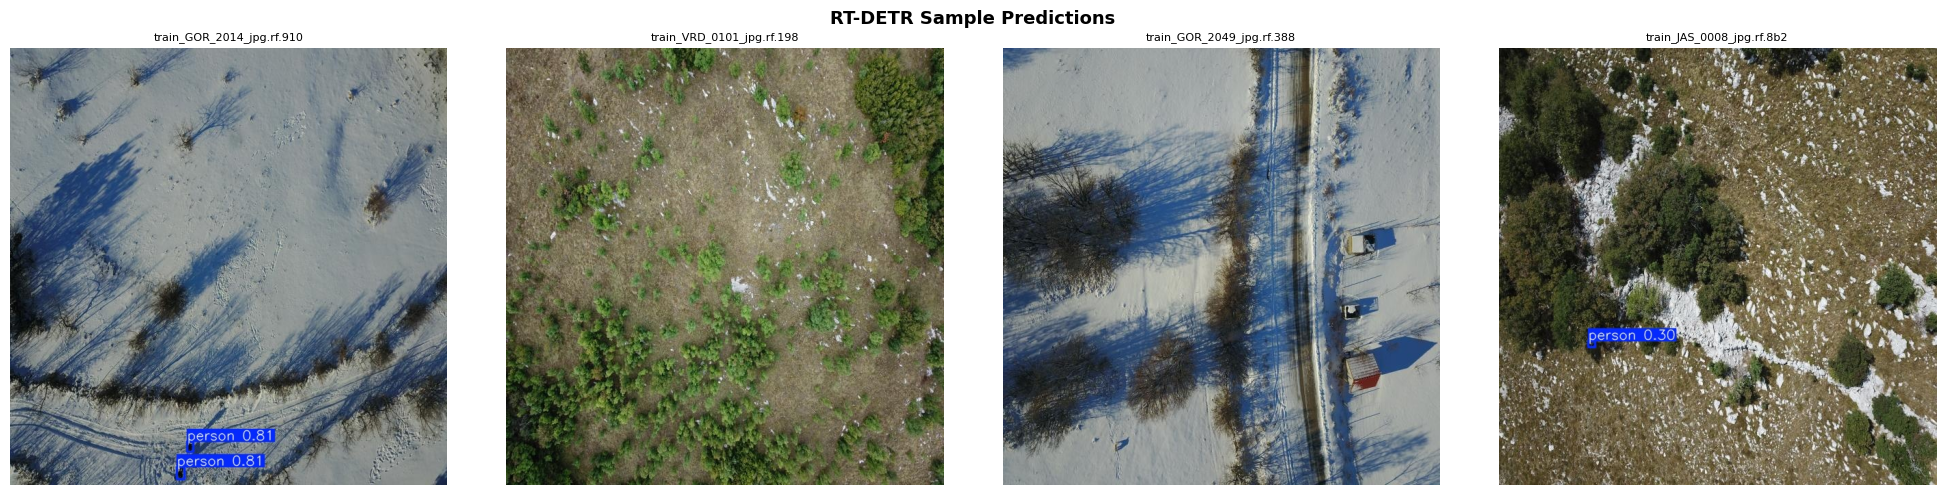

In [20]:
# Display sample prediction results
pred_dir = f'{PROJECT_DIR}/test_predictions'
pred_images = [f for f in os.listdir(pred_dir) if f.endswith(('.jpg', '.png'))]

if pred_images:
    sample = random.sample(pred_images, min(4, len(pred_images)))
    fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]
    for ax, f in zip(axes, sample):
        img = plt.imread(os.path.join(pred_dir, f))
        ax.imshow(img)
        ax.set_title(f[:25], fontsize=8)
        ax.axis('off')
    plt.suptitle('RT-DETR Sample Predictions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No prediction images found yet.')

## Step 12: SAHI Sliced Inference (Better for Tiny Objects)

Running SAHI on: test_BRS_0010_jpg.rf.8024d9f0b6452966edbc8fd0ac19f4ed.jpg
Performing prediction on 4 slices.
✅ SAHI results saved to: /content/sahi_output
   Detections found     : 1


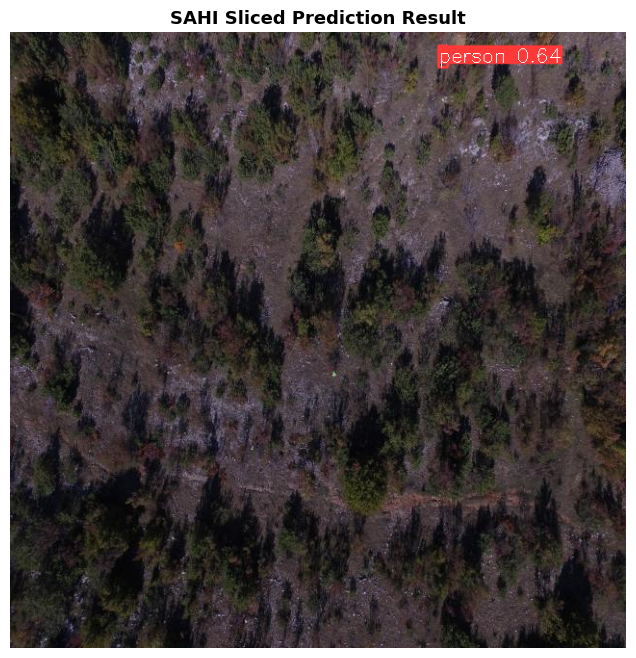

In [21]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

detection_model = AutoDetectionModel.from_pretrained(
    model_type           = 'ultralytics',
    model_path           = best_weights,
    confidence_threshold = 0.25,
    device               = f'cuda:{DEVICE}' if DEVICE != 'cpu' else 'cpu'
)

test_images_dir = f'{split_path}/test/images'
test_imgs       = os.listdir(test_images_dir)

if test_imgs:
    sample_img = os.path.join(test_images_dir, test_imgs[0])
    print(f'Running SAHI on: {test_imgs[0]}')

    result = get_sliced_prediction(
        sample_img,
        detection_model,
        slice_height         = 512,
        slice_width          = 512,
        overlap_height_ratio = 0.2,
        overlap_width_ratio  = 0.2
    )

    sahi_out = '/content/sahi_output'
    os.makedirs(sahi_out, exist_ok=True)
    result.export_visuals(export_dir=sahi_out)

    print(f'✅ SAHI results saved to: {sahi_out}')
    print(f'   Detections found     : {len(result.object_prediction_list)}')

    out_imgs = os.listdir(sahi_out)
    if out_imgs:
        img = plt.imread(os.path.join(sahi_out, out_imgs[0]))
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title('SAHI Sliced Prediction Result', fontsize=13, fontweight='bold')
        plt.show()

## Step 13: Save, Package & Download Model

> **Three download options provided:**
> 1. Direct Colab download (small files)
> 2. Save to Google Drive (recommended for large files)
> 3. Zip & download everything

In [22]:
import zipfile
import shutil

# ---- Save RT-DETR best model ----
final_model_path = '/content/rtdetr_heridal_best.pt'
shutil.copy(best_weights, final_model_path)
print(f'✅ RT-DETR model saved: {final_model_path}')

# ---- Save YOLOv8 baseline model ----
yolo_final_path = '/content/yolov8_heridal_baseline.pt'
shutil.copy(yolo_best_weights, yolo_final_path)
print(f'✅ YOLOv8 model saved: {yolo_final_path}')

# ---- Zip RT-DETR training results ----
results_zip = '/content/rtdetr_training_results.zip'
with zipfile.ZipFile(results_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
    run_dir = f'{PROJECT_DIR}/{NAME}'
    for root, _, files in os.walk(run_dir):
        for file in files:
            filepath = os.path.join(root, file)
            arcname  = os.path.relpath(filepath, PROJECT_DIR)
            zf.write(filepath, arcname)

print(f'✅ Results zipped: {results_zip}')

# ---- List all output files ----
print('\n📂 Files ready for download in /content/:')
for f in sorted(os.listdir('/content')):
    full_path = f'/content/{f}'
    if os.path.isfile(full_path):
        size = os.path.getsize(full_path) / 1e6
        print(f'  {f:<50} {size:.1f} MB')

✅ RT-DETR model saved: /content/rtdetr_heridal_best.pt
✅ YOLOv8 model saved: /content/yolov8_heridal_baseline.pt
✅ Results zipped: /content/rtdetr_training_results.zip

📂 Files ready for download in /content/:
  model_comparison.png                               0.0 MB
  rtdetr-l.pt                                        66.5 MB
  rtdetr_heridal_best.pt                             66.3 MB
  rtdetr_training_results.zip                        131.6 MB
  yolo26n.pt                                         5.5 MB
  yolov8_heridal_baseline.pt                         87.7 MB
  yolov8l.pt                                         87.8 MB


In [23]:
# ============================================================
# OPTION A: Direct browser download (best for files < 2 GB)
# ============================================================
from google.colab import files

print('📥 Downloading RT-DETR best model weights...')
files.download('/content/rtdetr_heridal_best.pt')

print('📥 Downloading YOLOv8 baseline model weights...')
files.download('/content/yolov8_heridal_baseline.pt')

print('📥 Downloading zipped training results (logs, curves, confusion matrix)...')
files.download('/content/rtdetr_training_results.zip')

print('📥 Downloading comparison chart...')
files.download('/content/model_comparison.png')

print('\n✅ Downloads initiated — check your browser download bar!')

📥 Downloading RT-DETR best model weights...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloading YOLOv8 baseline model weights...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

📥 Downloading comparison chart...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Downloads initiated — check your browser download bar!


In [24]:
# ============================================================
# OPTION B: Save to Google Drive (recommended for large files)
# — Run this cell if the direct download is too slow/fails —
# ============================================================
from google.colab import drive
drive.mount('/drive')

DRIVE_SAVE_PATH = '/drive/MyDrive/heridal_detection'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

# Copy key files to Drive
for src, dst_name in [
    ('/content/rtdetr_heridal_best.pt',      'rtdetr_heridal_best.pt'),
    ('/content/yolov8_heridal_baseline.pt',  'yolov8_heridal_baseline.pt'),
    ('/content/rtdetr_training_results.zip', 'rtdetr_training_results.zip'),
    ('/content/model_comparison.png',        'model_comparison.png'),
]:
    dst = os.path.join(DRIVE_SAVE_PATH, dst_name)
    shutil.copy(src, dst)
    size = os.path.getsize(dst) / 1e6
    print(f'✅ Saved to Drive: {dst}  ({size:.1f} MB)')

print(f'\n✅ All files saved to Google Drive at: {DRIVE_SAVE_PATH}')

Mounted at /drive
✅ Saved to Drive: /drive/MyDrive/heridal_detection/rtdetr_heridal_best.pt  (66.3 MB)
✅ Saved to Drive: /drive/MyDrive/heridal_detection/yolov8_heridal_baseline.pt  (87.7 MB)
✅ Saved to Drive: /drive/MyDrive/heridal_detection/rtdetr_training_results.zip  (131.6 MB)
✅ Saved to Drive: /drive/MyDrive/heridal_detection/model_comparison.png  (0.0 MB)

✅ All files saved to Google Drive at: /drive/MyDrive/heridal_detection
